# Differentially expressed genes in neighborhoods
This notebook will perform differential abundance analysis, using the approach generated by Andreas Fønss Møller in the hackathon

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_milo
# python -m ipykernel install --user --name scrna_cartography_milo --display-name "milo"

#### Load libraries

In [2]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc

# milo
import pertpy as pt
milo = pt.tl.Milo()
import mudata as md
from mudata import MuData

# Parallel processing
from joblib import Parallel, delayed, parallel_backend

# dataframes
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt 

import random
from sklearn.metrics.pairwise import euclidean_distances
from sklearn_ann.kneighbors.annoy import AnnoyTransformer 

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import diff_genes as dg
import misc as mi
import dg_milo as dm

/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Set up

In [3]:
# Create directories
mi.create_directories(dir_path = str(here('data/milo/files')))
mi.create_directories(dir_path = str(here('data/milo/de_analysis_groups')))
mi.create_directories(dir_path = str(here('data/milo/de_analysis_overall')))
mi.create_directories(dir_path = str(here('data/milo/plots')))
mi.create_directories(dir_path = str(here('data/milo/objects')))

/work/islet_cartography_scrna/data/milo/files Directory already exists!
/work/islet_cartography_scrna/data/milo/de_analysis_groups Directory created successfully!
/work/islet_cartography_scrna/data/milo/plots Directory already exists!
/work/islet_cartography_scrna/data/milo/objects Directory already exists!


In [4]:
# Paths
base_dir = str(here('data/milo/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
de_dir = os.path.join(base_dir, 'de_analysis_groups') 
de_overall_dir = os.path.join(base_dir, 'de_analysis_overall') 
objects_dir = os.path.join(base_dir, 'objects') 
anndata_dir = str(here('data/anndata/'))

#### Load

In [10]:
mdata =  md.read(os.path.join(objects_dir,"mdata_666_annotation.h5mu")) # object

In [153]:
adata = ad.read_h5ad(os.path.join(anndata_dir, "AH_combined.h5ad"))

#### Get mean expression per neighborhood

In [ ]:
# Get mean counts per neighborhood and save
milo.add_nhood_expression(mdata)
mean_nhood_expr = pd.DataFrame(
    mdata["milo"].varm["expr"].toarray(),
    index=mdata["milo"].var['index_cell'],        # neighbourhood IDs
    columns=mdata["rna"].var_names        # gene names
)
mean_nhood_expr.transpose().to_csv(
            os.path.join(files_dir, f"mean_counts_per_nhood.csv"),
            index_label="gene_symbol")

# save
mean_nhood_expr.transpose().to_csv(
            os.path.join(files_dir, f"mean_counts_per_nhood.csv"),
            index_label="gene_symbol")

#### Markers for neighborhoods

In [154]:
def find_nhood_groups(
    mdata, 
    da_res,
    SpatialFDR_threshold = 0.1,
    merge_discord = False,
    max_lfc_delta=None,
    overlap=5,
    use_only_sig = True,
    subset_nhoods: None | str = None,
):
    """Group neighborhoods based on filtered adjacency + community detection."""

    # Extract neighborhood membership matrix (cells × neighborhoods)
    nhs = mdata["rna"].obsm["nhoods"].copy()

    # Extract neighborhood adjacency (neighborhood × neighborhood)
    # Typically encodes overlap or connectivity strength
    nhood_adj = mdata["milo"].varp["nhood_connectivities"].copy()

    # test that order is the same
    pd.testing.assert_series_equal(
        mdata['milo'].var['index_cell'].reset_index(drop=True),
        da_res['index_cell'].reset_index(drop=True),
        check_dtype=False
    )

    # Boolean mask: which neighborhoods pass SpatialFDR threshold
    is_da = np.asarray(da_res.SpatialFDR <= SpatialFDR_threshold)

    if use_only_sig:

        # subset da_res to use only significant neighborhoods
        da_res = da_res.loc[is_da].copy()
        nhs = nhs[:, is_da]
        nhood_adj = nhood_adj[np.ix_(is_da, is_da)]

        # reset mask (all remaining are DA)
        is_da = np.ones(len(da_res), dtype=bool)

    # Optional: restrict analysis to a subset of neighborhoods using a query string
    if subset_nhoods is not None:

        # Subset DA results using pandas query (e.g. "celltype == 'T'")
        mask_da_res = (
            da_res
            .query(subset_nhoods)
            .copy()
        )

        # Build boolean mask aligned to index_cell
        mask = da_res["index_cell"].isin(mask_da_res["index_cell"]).values

        # Apply mask to results table
        da_res = da_res.loc[mask, :].copy()

        # Subset neighborhood membership matrix (columns = neighborhoods)
        nhs = nhs[:, mask].copy()

        # Subset adjacency matrix (rows and columns must match)
        nhood_adj = nhood_adj[:, mask]
        nhood_adj = nhood_adj[mask, :].copy()

        # Subset DA mask accordingly
        is_da = is_da[mask].copy()

    # If not merging discordant neighborhoods:
    # remove edges between neighborhoods with opposite logFC signs
    if merge_discord is False:

        # Compute pairwise sign agreement between DA neighborhoods
        # Outer product of logFC → positive = same sign, negative = opposite sign
        if use_only_sig:
            if len(da_res) > 0:
                lfc = da_res['logFC'].values
                discord_sign = np.sign(lfc[:, None] @ lfc[None, :]) < 0

                # Zero out edges between discordant pairs
                # (only within DA subset) (FIXED safe indexing)
                nhood_adj[discord_sign] = 0
        else:
            if is_da.sum() > 0:
                lfc = da_res.loc[is_da, 'logFC'].values
                discord_sign = np.sign(lfc[:, None] @ lfc[None, :]) < 0

                # Zero out edges between discordant pairs
                # (only within DA subset) (FIXED safe indexing)
                sub_adj = nhood_adj[np.ix_(is_da, is_da)]
                sub_adj[discord_sign] = 0
                nhood_adj[np.ix_(is_da, is_da)] = sub_adj

    # Remove weak edges based on minimum overlap threshold
    if overlap > 1:
        nhood_adj[nhood_adj < overlap] = 0

    # Optional: remove edges between neighborhoods with very different logFC
    if max_lfc_delta is not None:  

        # Compute full pairwise differences in logFC
        lfc = da_res['logFC'].values
        lfc_diff = np.abs(lfc[:, None] - lfc[None, :])

        # Zero edges where difference exceeds threshold
        nhood_adj[lfc_diff > max_lfc_delta] = 0

    # Convert weighted adjacency → binary graph (presence/absence of edge)
    nhood_adj = (nhood_adj > 0).astype(int)

    # MAke to array
    from scipy.sparse import issparse
    if issparse(nhood_adj):
        nhood_adj = nhood_adj.toarray()
    
    # Convert adjacency matrix to igraph object (undirected graph)
    g = sc._utils.get_igraph_from_adjacency(nhood_adj, directed=False)

    # Run community detection (Louvain / multilevel algorithm)
    weights = None  # unweighted graph
    part = g.community_multilevel(weights=weights)

    # Extract community membership for each neighborhood
    groups = np.array(part.membership)

    # Convert to string labels (for storage in AnnData)
    groups = groups.astype(int).astype(str)

    # Always return DataFrame 
    nhood_groups_df = pd.DataFrame(
        {"nhood_groups": groups},
        index=da_res["index_cell"].values
    )

    return nhood_groups_df

#### T2DM per group analysos

Load data

In [155]:
res_t2d = pd.read_csv(os.path.join(files_dir, "t2d_vs_nd.csv"), index_col=0) # diff abundance results
res_t2d.reset_index(drop=True, inplace = True)
df = pd.read_csv(os.path.join(files_dir, "cells_in_neighborhood.csv"), index_col=0) # cells in neighborhoods
df.reset_index(drop=True, inplace = True)

Define groups of neighborhoods that are closely connected within each nhood annotation (only use significant nhoods

nhoods that overlap with more than 5 cells, and they should not have more than 0.1 logFC difference between them

In [156]:
all_results = []

for anno in res_t2d["nhood_annotation"].unique():
    print(f"Processing {anno}")

    df_groups = find_nhood_groups(
        mdata,
        da_res=res_t2d,
        subset_nhoods=f"nhood_annotation == '{anno}'"
    )

    # Add further annotation
    df_groups["nhood_annotation"] = anno
    df_groups['nhood_groups'] = df_groups['nhood_annotation'] + '_' + df_groups['nhood_groups']
    del df_groups["nhood_annotation"]
    all_results.append(df_groups)

# Combine
nhood_groups = pd.concat(all_results)
nhood_groups = nhood_groups.reset_index().rename(columns={"index": "index_cell"})

Processing alpha
Processing ductal
Processing gamma
Processing endothelial_islet
Processing beta


/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient

Processing mixed
Processing ductal_mucin
Processing delta
Processing myeloid
Processing stellate_activated


/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient

Processing acinar_reg_plus
Processing acinar
Processing stellate_quiescent
Processing mast
Processing epsilon


/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil 

Processing endmt_early


/tmp/ipykernel_2083/1285577242.py:93: SparseEfficiencyWarning: Comparing a sparse matrix with 5 using < is inefficient. Try using >= instead.
  nhood_adj[nhood_adj < overlap] = 0


Merge data

In [157]:
# Combine results
df['index_cell'] = df['neighborhood']
# merge with groups
df = df.merge(nhood_groups, how = "inner", on = "index_cell")
# merge with res data
df = df.merge(res_t2d, how = "inner", on = "index_cell")
# add disease information and sample
df = df.merge(mdata['rna'].obs[['disease_harmonized', 'ic_id_platform_adjusted_sample', 'manual_annotation']].reset_index().rename(columns={"index": "index_cell"}), how = "inner", on = "index_cell")

In [158]:
pd.crosstab(
    df["nhood_groups"],
    df["manual_annotation"])

manual_annotation,acinar,alpha,beta,cycling,delta,ductal,ductal_mucin,endmt_early,endothelial_islet,epsilon,gamma,mast,myeloid,stellate_activated,stellate_quiescent
nhood_groups,,,,,,,,,,,,,,,
acinar_0,77213,0,0,0,0,0,0,0,0,0,0,0,0,0,0
alpha_0,0,13838,0,0,0,0,0,0,0,0,0,0,0,0,0
alpha_1,0,0,0,2237,0,0,0,0,0,2294,0,0,0,0,0
alpha_2,0,3102,0,0,0,0,0,0,0,0,0,0,0,0,0
alpha_3,0,5018,0,0,0,0,0,0,0,0,0,0,0,0,0
beta_0,0,0,100107,0,0,0,0,0,0,0,0,0,0,0,0
beta_1,0,0,52108,0,0,0,0,0,0,0,0,0,0,0,0
beta_2,0,0,79805,0,0,0,0,0,0,0,0,0,0,0,0
delta_0,0,0,0,0,45867,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='nhood_groups'>

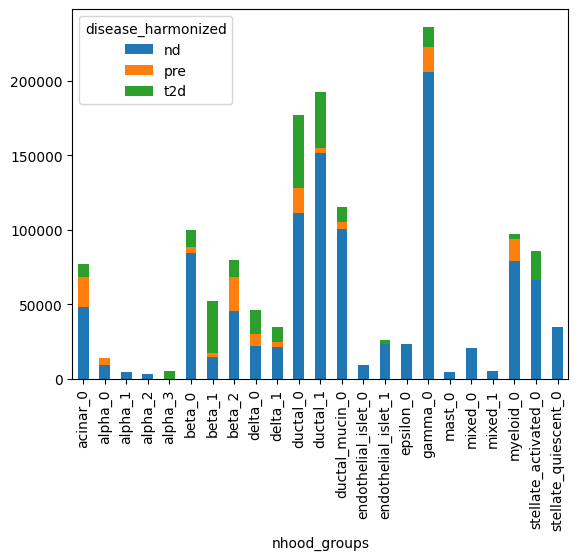

In [148]:
pd.crosstab(
    df["nhood_groups"],
    df["disease_harmonized"]
).plot(kind="bar", stacked=True)

<Axes: xlabel='nhood_groups'>

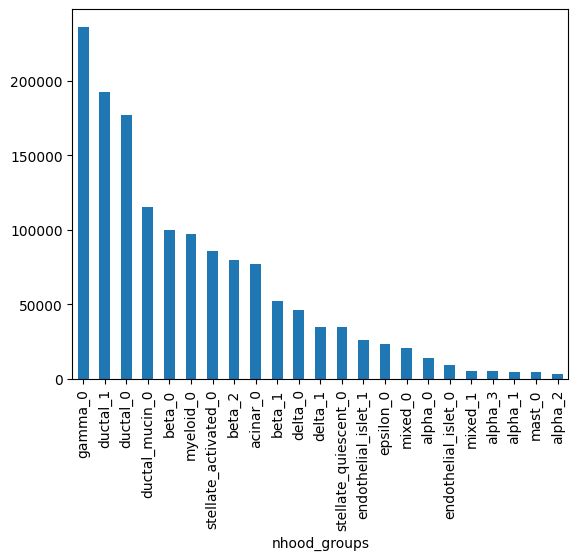

In [149]:
df["nhood_groups"].value_counts().plot(kind="bar")

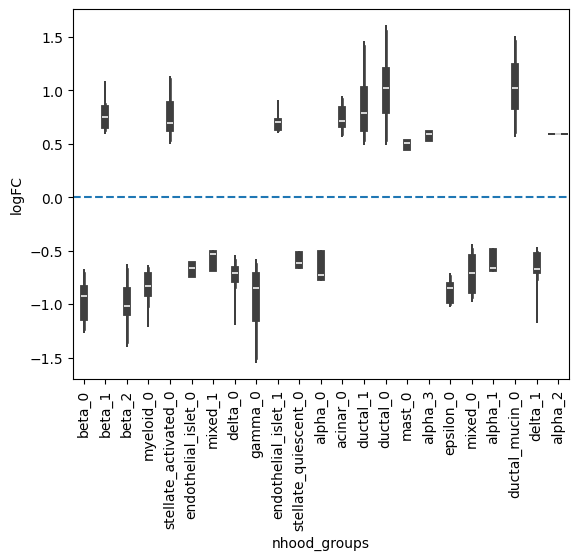

In [152]:
import seaborn as sns

sns.violinplot(data=df, x="nhood_groups", y="logFC")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=90)
plt.show()

#### DE analysis per group

In [ ]:
celltype_key = "manual_annotation"
group_key = "nhood_groups"
sample_key = "ic_id_platform_adjusted_sample"

prefix = "t2d_vs_nd"

min_cells = 20   # minimum number of cells per sample per group
min_rep = 8      # minimum number of samples (replicates)

for celltype in df[celltype_key].dropna().unique():
    print(f"\nProcessing cell type: {celltype}")

    # Subset to one cell type
    df_cell = df.loc[df[celltype_key] == celltype].copy()

    # Keep only group information and remove duplicate cells
    df_cell = df_cell[[group_key]].loc[~df_cell.index.duplicated(keep="first")]

    # Get neighborhood groups within this cell type
    groups = df_cell[group_key].dropna().unique()

    # Skip if only one group
    if len(groups) < 2:
        print(f"Skipping {celltype}: only one group")
        continue

    for group in groups:
        print(f"  DE: group {group} vs other")

        comparison_col = f"group_{group}_vs_other"

        # Define comparison: one group vs all others
        df_cell[comparison_col] = df_cell[group_key].apply(
            lambda x: group if x == group else "other"
        )

        # Subset AnnData to relevant cells
        subset = adata[adata.obs_names.isin(df_cell.index)].copy()

        # Merge grouping info into AnnData
        subset.obs = subset.obs.merge(
            df_cell[[comparison_col]],
            how="left",
            left_index=True,
            right_index=True
        )

        # Count cells per sample per group
        counts = (
            subset.obs
            .groupby([sample_key, comparison_col])
            .size()
            .unstack(fill_value=0)
        )

        # Check replicate thresholds
        valid_group = (counts.get(group, 0) >= min_cells).sum()
        valid_other = (counts.get("other", 0) >= min_cells).sum()

        if valid_group < min_rep or valid_other < min_rep:
            print(f"    Skipping group {group}: insufficient replicates")
            continue

        # Keep only valid samples
        valid_samples_group = counts.index[counts.get(group, 0) >= min_cells]
        valid_samples_other = counts.index[counts.get("other", 0) >= min_cells]
        valid_samples = set(valid_samples_group) | set(valid_samples_other)

        subset = subset[subset.obs[sample_key].isin(valid_samples)].copy()

        # Prepare pseudobulk DESeq2 input
        dds = dg.prepare_pseudobulk_deseq_analysis(
            ad=subset,
            sample_key=sample_key,
            cluster_key=comparison_col,
            no_subset=True,
            n_cells=25,
            design=f"~ {sample_key} + {comparison_col}",
            layer="counts",
            func="sum",
            return_all=False,
            workers=30,
        )

        # Run DE
        res = dg.diff_genes_two_clusters(
            dds_obj=dds,
            cluster_index=comparison_col,
            cluster_1=group,
            cluster_2="other",
            workers=30
        )

        # Save DE results
        res.to_csv(
            os.path.join(files_dir, f"{prefix}_{celltype}_group_{group}_vs_other.csv"),
            index_label="gene_symbol",
        )

        # Save normalized counts
        norm_df = pd.DataFrame(
            dds.layers["normed_counts"],
            index=dds.obs_names,
            columns=dds.var_names
        )

        norm_df.T.to_csv(
            os.path.join(files_dir, f"{prefix}_{celltype}_group_{group}_norm_counts.csv"),
            index_label="gene_symbol",
        )

#### Save

In [147]:
df.to_csv(os.path.join(de_dir, f"nhood_groups_for_de.csv"))

##### Find differentially expressed genes

##### T2DM overall analysis

In [ ]:
res_t2d = pd.read_csv(os.path.join(files_dir, "t2d_vs_nd.csv"), index_col=0) # diff abundance results
res_t2d.reset_index(drop=True, inplace = True)
df = pd.read_csv(os.path.join(files_dir, "cells_in_neighborhood.csv"), index_col=0) # cells in neighborhoods
df.reset_index(drop=True, inplace = True)

In [ ]:
# Combine results
df['index_cell'] = df['neighborhood']
df = df.merge(res_t2d, how = "left", on = "index_cell")

In [ ]:
# Add direction of regulation
df.loc[(df["SpatialFDR"] <= 0.1) & (df["logFC"] > 0), 'direction'] = 'up'
df.loc[(df["SpatialFDR"] <= 0.1) & (df["logFC"] < 0), 'direction'] = 'down'
df.loc[df["direction"].isna(), 'direction'] = "no_change"
# Add a key for differential expression
df['diff_key'] = df['nhood_annotation'] + '_' + df['direction']
# Set index
df = df.set_index('cell')

#### Diffenretially expressed genes one vs the rest

In [ ]:
nhood_anno = "nhood_annotation"
cluster_key = "diff_key"
sample_key = "ic_id_platform_adjusted_sample"
prefix = "t2d_vs_nd"
min_cells = 20 # minimum number of cells 
min_rep = 8 # minimum number of replicates

for anno_id in df[nhood_anno].unique():
    print(f"Processing {anno_id}")

    # Subset df to only contain annotation - drop duplicated cells and set cell as index (for merge)
    df_sub = df.loc[df[nhood_anno] == anno_id].copy()

    # Remove duplicated cells
    df_sub = df_sub[[cluster_key]].loc[~df_sub.index.duplicated(keep="first")]

    # Get cluster ids to test
    cluster_ids = [
        x
        for x in df_sub[cluster_key].unique()
        if isinstance(x, str) and (x.endswith("_up") or x.endswith("_down"))
    ]

    if len(cluster_ids) == 0:
        print(f"No differentally abundance neighborshoods for {anno_id} skipping...")
        continue

    # Create clustering columns
    for cluster_id in cluster_ids:
        print(f"Differential expression for {cluster_id}")
        col_name = f"{cluster_id}_vs_other"
        df_sub[col_name] = df_sub[cluster_key].apply(
            lambda x: cluster_id if x == cluster_id else "other"
        )

        # subset ann data object to neighborhoods of interest
        subset = adata[adata.obs_names.isin(df_sub.index.unique())].copy()

        subset.obs = subset.obs.merge(
            df_sub, how="left", left_index=True, right_index=True
        )

        # Check that we have enough cells per samples and samples for deseq analysis 
        counts = (
            subset.obs
            .groupby([sample_key, col_name])
            .size()
            .unstack(fill_value=0)
        )
        
        valid_cluster = (counts.get(cluster_id, 0) >= min_cells).sum()
        valid_other = (counts.get("other", 0) >= min_cells).sum()
        
        if valid_cluster < min_rep or valid_other < min_rep:
            print(f"Skipping {cluster_id}: insufficient replicates")
            continue

        # Remove samples with too few cells
        valid_samples_cluster = counts.index[counts.get(cluster_id, 0) >= min_cells]
        valid_samples_other = counts.index[counts.get("other", 0) >= min_cells]
        valid_samples = set(valid_samples_cluster) | set(valid_samples_other)

        # Remove samples from adata object
        subset = subset[subset.obs[sample_key].isin(valid_samples)].copy()

        dds = dg.prepare_pseudobulk_deseq_analysis(
            ad=subset,
            sample_key=sample_key,
            cluster_key=col_name,
            no_subset=True,
            n_cells=25,
            design=f"~ {sample_key} + {col_name}",
            layer="counts",
            func="sum",
            return_all=False,
            workers=30,
        )

        # Define comparison
        c1 = cluster_id
        c2 = "other"

        # Wald test
        res = dg.diff_genes_two_clusters(
            dds_obj=dds, cluster_index=col_name, cluster_1=c1, cluster_2=c2, workers=30
        )
        # Save results
        res.to_csv(
            os.path.join(files_dir, f"{prefix}_deg_{cluster_id}_vs_other.csv"),
            index_label="gene_symbol",
        )

        # Save normalized counts
        norm_df = pd.DataFrame(
            dds.layers["normed_counts"], index=dds.obs_names, columns=dds.var_names
        )

        norm_df.transpose().to_csv(
            os.path.join(files_dir, f"{prefix}_norm_counts_{cluster_id}_vs_other.csv"),
            index_label="gene_symbol",
        )

#### Prediabetes overall analysis: one vs the rest

In [170]:
res_pre = pd.read_csv(os.path.join(files_dir, "pre_vs_nd.csv"), index_col=0) # diff abundance results
res_pre.reset_index(drop=True, inplace = True)
df = pd.read_csv(os.path.join(files_dir, "cells_in_neighborhood.csv"), index_col=0) # cells in neighborhoods
df.reset_index(drop=True, inplace = True)
# Combine results
df['index_cell'] = df['neighborhood']
df = df.merge(res_pre, how = "left", on = "index_cell")
# Add direction of regulation
df.loc[(df["SpatialFDR"] <= 0.1) & (df["logFC"] > 0), 'direction'] = 'up'
df.loc[(df["SpatialFDR"] <= 0.1) & (df["logFC"] < 0), 'direction'] = 'down'
df.loc[df["direction"].isna(), 'direction'] = "no_change"
# Add a key for differential expression
df['diff_key'] = df['nhood_annotation'] + '_' + df['direction']
# Set index
df = df.set_index('cell')

In [166]:
#df = df.merge(mdata['rna'].obs[['disease_harmonized', 'ic_id_platform_adjusted_sample', 'manual_annotation']].reset_index().rename(columns={"index": "index_cell"}), how = "left", on = "index_cell")

In [168]:
#df.to_csv(os.path.join(files_dir, f"pre_for_de_overall.csv"))

In [171]:
nhood_anno = "nhood_annotation"
cluster_key = "diff_key"
sample_key = "ic_id_platform_adjusted_sample"
prefix = "pre_vs_nd"
min_cells = 20 # minimum number of cells 
min_rep = 8 # minimum number of replicates

for anno_id in df[nhood_anno].unique():
    print(f"Processing {anno_id}")

    # Subset df to only contain annotation - drop duplicated cells and set cell as index (for merge)
    df_sub = df.loc[df[nhood_anno] == anno_id].copy()

    # Remove duplicated cells
    df_sub = df_sub[[cluster_key]].loc[~df_sub.index.duplicated(keep="first")]

    # Get cluster ids to test
    cluster_ids = [
        x
        for x in df_sub[cluster_key].unique()
        if isinstance(x, str) and (x.endswith("_up") or x.endswith("_down"))
    ]

    if len(cluster_ids) == 0:
        print(f"No differentally abundance neighborshoods for {anno_id} skipping...")
        continue

    # Create clustering columns
    for cluster_id in cluster_ids:
        print(f"Differential expression for {cluster_id}")
        col_name = f"{cluster_id}_vs_other"
        df_sub[col_name] = df_sub[cluster_key].apply(
            lambda x: cluster_id if x == cluster_id else "other"
        )

        # subset ann data object to neighborhoods of interest
        subset = adata[adata.obs_names.isin(df_sub.index.unique())].copy()

        subset.obs = subset.obs.merge(
            df_sub, how="left", left_index=True, right_index=True
        )

        # Check that we have enough cells per samples and samples for deseq analysis 
        counts = (
            subset.obs
            .groupby([sample_key, col_name])
            .size()
            .unstack(fill_value=0)
        )
        
        valid_cluster = (counts.get(cluster_id, 0) >= min_cells).sum()
        valid_other = (counts.get("other", 0) >= min_cells).sum()
        
        if valid_cluster < min_rep or valid_other < min_rep:
            print(f"Skipping {cluster_id}: insufficient replicates")
            continue

        # Remove samples with too few cells
        valid_samples_cluster = counts.index[counts.get(cluster_id, 0) >= min_cells]
        valid_samples_other = counts.index[counts.get("other", 0) >= min_cells]
        valid_samples = set(valid_samples_cluster) | set(valid_samples_other)

        # Remove samples from adata object
        subset = subset[subset.obs[sample_key].isin(valid_samples)].copy()

        dds = dg.prepare_pseudobulk_deseq_analysis(
            ad=subset,
            sample_key=sample_key,
            cluster_key=col_name,
            no_subset=True,
            n_cells=25,
            design=f"~ {sample_key} + {col_name}",
            layer="counts",
            func="sum",
            return_all=False,
            workers=60,
        )

        # Define comparison
        c1 = cluster_id
        c2 = "other"

        # Wald test
        res = dg.diff_genes_two_clusters(
            dds_obj=dds, cluster_index=col_name, cluster_1=c1, cluster_2=c2, workers=30
        )
        # Save results
        res.to_csv(
            os.path.join(files_dir, f"{prefix}_deg_{cluster_id}_vs_other.csv"),
            index_label="gene_symbol",
        )

        # Save normalized counts
        norm_df = pd.DataFrame(
            dds.layers["normed_counts"], index=dds.obs_names, columns=dds.var_names
        )

        norm_df.transpose().to_csv(
            os.path.join(files_dir, f"{prefix}_norm_counts_{cluster_id}_vs_other.csv"),
            index_label="gene_symbol",
        )

Processing beta
Differential expression for beta_up


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.61 seconds.

Fitting dispersions...
... done in 81.35 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.88 seconds.

Fitting MAP dispersions...
... done in 60.93 seconds.

Fitting LFCs...
... done in 85.02 seconds.

Calculating cook's distance...
... done in 1.31 seconds.

Replacing 0 outlier genes.



Processing mixed
Differential expression for mixed_down


...

Differential expression for alpha_down


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.78 seconds.

Fitting dispersions...
... done in 93.31 seconds.

Fitting dispersion trend curve...
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 1.28 seconds.

Fitting MAP dispersions...
... done in 94.18 seconds.

Fitting LFCs...


KeyboardInterrupt: 